## Load necessary library files

In [61]:
import torch
from torch.utils.data import Dataset, DataLoader
from torch import from_numpy as tnsr
import torch.nn as nn
import numpy as np
import pandas as pd
from tqdm import tqdm
import seaborn as sns
import matplotlib.pyplot as plt

## Define 1D CNN
The architecture is composed of 2 1D convolutional layers followed by a linear layer and a task specific head.

In [169]:
tokens = ['A', 'B', 'C', 'D', 'E', 'F', 'G']

class cnn(torch.nn.Module):
    def __init__(self):
        super(cnn, self).__init__()
        self.layer1 = nn.Conv1d(len(tokens), 4, kernel_size=3)
        self.activation1 = nn.ReLU(inplace=True)
        self.layer2 = nn.Conv1d(4, 8, kernel_size=3)
        self.activation2 = nn.ReLU(inplace=True)

        
        self.layer3 = nn.Linear(32, 10)
        self.activation3 = nn.ReLU(inplace=True)
        
        self.layer4_task1 = nn.Linear(10, len(tokens))
        self.layer4_task2 = nn.Linear(10, len(tokens))
        
    def forward(self, x, task=1):
        x = self.layer1(x)
        x = self.activation1(x)
        x = self.layer2(x)
        x = self.activation2(x)
        x = x.view(-1)
        #print(x.shape)
        x = self.layer3(x)
        x = self.activation3(x)

        if task==1:
            x = self.layer4_task1(x)
        else:
            x = self.layer4_task2(x)
        
        x = torch.nn.functional.softmax(x)

        return x

## Define dataset with one hot encoding

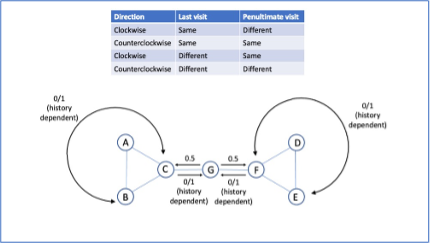

In [170]:
class Dataset_converter(Dataset):
    def __init__(self, data, window=2, task=1):
        one_hot_encoded = np.zeros((len(tokens), len(data)), dtype=float)
        for ii, token in enumerate(data):
            if task == 1:
                one_hot_encoded[ord(token)-65,ii] = 1
            else:
                if token == 'A':
                    idx = 1
                elif token == 'B':
                    idx = 0
                elif token == 'D':
                    idx = 4
                elif token == 'E':
                    idx = 3
                else:
                    idx = ord(token)-65
                    
                one_hot_encoded[idx,ii] = 1
        
        self.X = np.zeros((len(data)-window, len(tokens), window))
        self.y = np.zeros((len(data)-window, len(tokens)))

        for ii in range(len(data)-window):
            self.X[ii] = one_hot_encoded[:,ii:ii+window]
            self.y[ii] = one_hot_encoded[:,ii+window]

        self.X = tnsr(self.X).float()
        self.y = tnsr(self.y).float()

    def __getitem__(self, index):
        return self.X[index], self.y[index]

    def __len__(self):
        return self.X.shape[0]

## Load dataset

In [171]:
data = pd.read_csv("../Seq_500000.txt")['seq'][0]

## Perform the experiment for multiheaded sequential training (each repeated 10 times). Note that it results in forgetting of Task 1.

In [191]:
reps = 10
layer_no = [1,2,3,4,5]
lr = 1e-2
window = 8
test_acc1 = np.zeros((reps, len(data)), dtype=float)
test_acc2 = np.zeros((reps, len(data)), dtype=float)

task1 = Dataset_converter(data, window)
task2 = Dataset_converter(data, window, task=2)

for rep in tqdm(range(reps)):
    torch.manual_seed(rep)
    model = cnn()
    train_loader_task1 = DataLoader(task1, batch_size=1, shuffle=False) 
    train_loader_task2 = DataLoader(task2, batch_size=1, shuffle=False) 
    
    optimizer = torch.optim.SGD(model.parameters(), lr=lr, momentum=0.9)
    criterion = torch.nn.MSELoss()

    total = 0
    correct1 = np.zeros(10000,dtype=float)
    correct2 = np.zeros(10000,dtype=float)
    jj = 0
    for (X1, y1), (X2, y2) in zip(train_loader_task1, train_loader_task2):
        optimizer.zero_grad()

        if jj < 250000:
            predicted_y1 = model(X1)
            loss = criterion(predicted_y1, y1)
            loss.backward()
            optimizer.step()
        else:
            predicted_y2 = model(X2, task=2)
            loss = criterion(predicted_y2, y2)
            loss.backward()
            optimizer.step()

        with torch.no_grad():
            total += 1

            if jj < 250000:
                predicted_y2 = model(X2, task=2)
            else:
                predicted_y1 = model(X1)

            if y1.argmax() == predicted_y1.argmax():
                    correct1[jj%10000] = 1
            else:
                correct1[jj%10000] = 0

            if y2.argmax() == predicted_y2.argmax():
                    correct2[jj%10000] = 1
            else:
                correct2[jj%10000] = 0

            test_acc1[rep,jj] = np.sum(correct1)/total if total<10000 else np.sum(correct1)/10000
            test_acc2[rep,jj] = np.sum(correct2)/total if total<10000 else np.sum(correct2)/10000

            if jj%10000==0:
                print(f'Iter : {jj+1}, loss: {loss:.4f}, accuracy task 1: {test_acc1[rep,jj]}, accuracy task 2: {test_acc2[rep,jj]}')
            jj += 1
            

  0%|                                                                                                                                                   | 0/10 [00:00<?, ?it/s]/var/folders/gv/wp457yys7h73m9dkm35g8l4r0000gn/T/ipykernel_34924/1982273616.py:33: UserWarning: Implicit dimension choice for softmax has been deprecated. Change the call to include dim=X as an argument.
  x = torch.nn.functional.softmax(x)


Iter : 1, loss: 0.1341, accuracy task 1: 0.0, accuracy task 2: 0.0
Iter : 10001, loss: 0.0718, accuracy task 1: 0.521, accuracy task 2: 0.1649
Iter : 20001, loss: 0.0007, accuracy task 1: 0.7936, accuracy task 2: 0.0982
Iter : 30001, loss: 0.0027, accuracy task 1: 0.8158, accuracy task 2: 0.1133
Iter : 40001, loss: 0.0000, accuracy task 1: 0.9026, accuracy task 2: 0.1732
Iter : 50001, loss: 0.0000, accuracy task 1: 0.9029, accuracy task 2: 0.1848
Iter : 60001, loss: 0.0000, accuracy task 1: 0.8959, accuracy task 2: 0.1734
Iter : 70001, loss: 0.0000, accuracy task 1: 0.9007, accuracy task 2: 0.1759
Iter : 80001, loss: 0.0000, accuracy task 1: 0.9012, accuracy task 2: 0.1903
Iter : 90001, loss: 0.0000, accuracy task 1: 0.8989, accuracy task 2: 0.2027
Iter : 100001, loss: 0.0000, accuracy task 1: 0.8966, accuracy task 2: 0.2139
Iter : 110001, loss: 0.0000, accuracy task 1: 0.8972, accuracy task 2: 0.2142
Iter : 120001, loss: 0.0000, accuracy task 1: 0.8996, accuracy task 2: 0.2138
Iter : 

 10%|█████████████▊                                                                                                                            | 1/10 [02:38<23:43, 158.21s/it]

Iter : 1, loss: 0.1222, accuracy task 1: 0.0, accuracy task 2: 0.0
Iter : 10001, loss: 0.0553, accuracy task 1: 0.4983, accuracy task 2: 0.1232
Iter : 20001, loss: 0.0005, accuracy task 1: 0.7711, accuracy task 2: 0.1441
Iter : 30001, loss: 0.0002, accuracy task 1: 0.8209, accuracy task 2: 0.1584
Iter : 40001, loss: 0.0002, accuracy task 1: 0.9022, accuracy task 2: 0.1706
Iter : 50001, loss: 0.0000, accuracy task 1: 0.9038, accuracy task 2: 0.1809
Iter : 60001, loss: 0.0000, accuracy task 1: 0.8952, accuracy task 2: 0.1812
Iter : 70001, loss: 0.0000, accuracy task 1: 0.9021, accuracy task 2: 0.1862
Iter : 80001, loss: 0.0000, accuracy task 1: 0.8997, accuracy task 2: 0.1742
Iter : 90001, loss: 0.0000, accuracy task 1: 0.8985, accuracy task 2: 0.1798
Iter : 100001, loss: 0.0000, accuracy task 1: 0.8986, accuracy task 2: 0.176
Iter : 110001, loss: 0.0000, accuracy task 1: 0.8983, accuracy task 2: 0.1717
Iter : 120001, loss: 0.0000, accuracy task 1: 0.9001, accuracy task 2: 0.1774
Iter : 

 20%|███████████████████████████▌                                                                                                              | 2/10 [05:15<21:03, 157.96s/it]

...

 80%|██████████████████████████████████████████████████████████████████████████████████████████████████████████████▍                           | 8/10 [20:59<05:12, 156.07s/it]

Iter : 1, loss: 0.1135, accuracy task 1: 1.0, accuracy task 2: 0.0
Iter : 10001, loss: 0.0789, accuracy task 1: 0.4975, accuracy task 2: 0.1217
Iter : 20001, loss: 0.0027, accuracy task 1: 0.7777, accuracy task 2: 0.1036
Iter : 30001, loss: 0.0000, accuracy task 1: 0.8586, accuracy task 2: 0.1195
Iter : 40001, loss: 0.0000, accuracy task 1: 0.8993, accuracy task 2: 0.1197
Iter : 50001, loss: 0.0000, accuracy task 1: 0.9053, accuracy task 2: 0.099
Iter : 60001, loss: 0.0000, accuracy task 1: 0.8967, accuracy task 2: 0.0968
Iter : 70001, loss: 0.0000, accuracy task 1: 0.8982, accuracy task 2: 0.0969
Iter : 80001, loss: 0.0000, accuracy task 1: 0.8999, accuracy task 2: 0.0997
Iter : 90001, loss: 0.0000, accuracy task 1: 0.8983, accuracy task 2: 0.0985
Iter : 100001, loss: 0.0000, accuracy task 1: 0.8983, accuracy task 2: 0.0993
Iter : 110001, loss: 0.0000, accuracy task 1: 0.8975, accuracy task 2: 0.1011
Iter : 120001, loss: 0.0000, accuracy task 1: 0.9001, accuracy task 2: 0.0991
Iter : 

 90%|████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████▏             | 9/10 [23:40<02:37, 157.51s/it]

Iter : 1, loss: 0.1288, accuracy task 1: 0.0, accuracy task 2: 0.0
Iter : 10001, loss: 0.0699, accuracy task 1: 0.5445, accuracy task 2: 0.1986
Iter : 20001, loss: 0.0031, accuracy task 1: 0.7705, accuracy task 2: 0.2445
Iter : 30001, loss: 0.0021, accuracy task 1: 0.8007, accuracy task 2: 0.2483
Iter : 40001, loss: 0.0000, accuracy task 1: 0.8036, accuracy task 2: 0.2549
Iter : 50001, loss: 0.0001, accuracy task 1: 0.8017, accuracy task 2: 0.2623
Iter : 60001, loss: 0.0000, accuracy task 1: 0.796, accuracy task 2: 0.2794
Iter : 70001, loss: 0.0000, accuracy task 1: 0.8024, accuracy task 2: 0.2863
Iter : 80001, loss: 0.0000, accuracy task 1: 0.8027, accuracy task 2: 0.3014
Iter : 90001, loss: 0.0000, accuracy task 1: 0.7991, accuracy task 2: 0.3013
Iter : 100001, loss: 0.0000, accuracy task 1: 0.7993, accuracy task 2: 0.3039
Iter : 110001, loss: 0.0001, accuracy task 1: 0.8017, accuracy task 2: 0.3149
Iter : 120001, loss: 0.0000, accuracy task 1: 0.8026, accuracy task 2: 0.3289
Iter : 

100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 10/10 [26:16<00:00, 157.63s/it]


## Plot the result

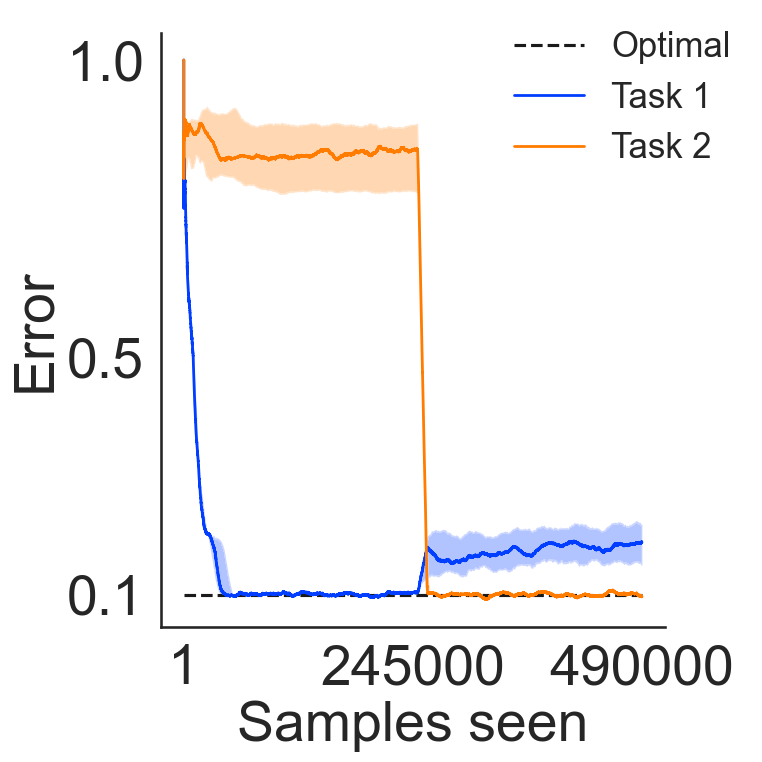

In [192]:
sns.set(
        color_codes=True, palette="bright", style="white", context="talk", font_scale=1.5
    )
font = 40
samples_to_show = 490000

fig, ax = plt.subplots(1, 1, figsize=(8,8))

ax.hlines(0.1, 0, samples_to_show, linestyles='dashed', label='Optimal', color='k')

ax.plot(np.arange(1,samples_to_show+1), np.median(1-test_acc1[:,:samples_to_show],axis=0),linewidth=2, label='Task 1')
ax.fill_between(np.arange(1,samples_to_show+1), np.quantile(1-test_acc1[:,:samples_to_show], 0.25, axis=0), np.quantile(1-test_acc1[:,:samples_to_show], 0.75, axis=0), alpha=.3)

ax.plot(np.arange(1,samples_to_show+1), np.median(1-test_acc2[:,:samples_to_show],axis=0),linewidth=2, label='Task 2')
ax.fill_between(np.arange(1,samples_to_show+1), np.quantile(1-test_acc2[:,:samples_to_show], 0.25, axis=0), np.quantile(1-test_acc2[:,:samples_to_show], 0.75, axis=0), alpha=.3)

leg = fig.legend(fontsize=25, frameon=False)


ax.set_xticks([1, samples_to_show//2, samples_to_show])
ax.set_yticks([0.1, 0.5, 1.0])

ax.set_xlabel('Samples seen', fontsize=font)
ax.set_ylabel('Error', fontsize=font)

ax.tick_params(labelsize=40)
right_side = ax.spines["right"]
right_side.set_visible(False)
top_side = ax.spines["top"]
top_side.set_visible(False)

plt.tight_layout()


## Perform the experiment for multiheaded interleaved training (each repeated 10 times). Note that it overcomes forgetting.

In [189]:
reps = 10
layer_no = [1,2,3,4,5]
lr = 1e-2
window = 8
test_acc1 = np.zeros((reps, len(data)), dtype=float)
test_acc2 = np.zeros((reps, len(data)), dtype=float)

task1 = Dataset_converter(data, window)
task2 = Dataset_converter(data, window, task=2)

for rep in tqdm(range(reps)):
    torch.manual_seed(rep)
    model = cnn()
    train_loader_task1 = DataLoader(task1, batch_size=1, shuffle=False) 
    train_loader_task2 = DataLoader(task2, batch_size=1, shuffle=False) 
    
    optimizer = torch.optim.SGD(model.parameters(), lr=lr, momentum=0.9)
    criterion = torch.nn.MSELoss()

    total = 0
    correct1 = np.zeros(10000,dtype=float)
    correct2 = np.zeros(10000,dtype=float)
    jj = 0
    for (X1, y1), (X2, y2) in zip(train_loader_task1, train_loader_task2):
        optimizer.zero_grad()

        if jj%2:
            predicted_y1 = model(X1)
            loss = criterion(predicted_y1, y1)
            loss.backward()
            optimizer.step()
        else:
            predicted_y2 = model(X2, task=2)
            loss = criterion(predicted_y2, y2)
            loss.backward()
            optimizer.step()

        with torch.no_grad():
            total += 1

            if jj%2:
                predicted_y2 = model(X2, task=2)
            else:
                predicted_y1 = model(X1)

            if y1.argmax() == predicted_y1.argmax():
                    correct1[jj%10000] = 1
            else:
                correct1[jj%10000] = 0

            if y2.argmax() == predicted_y2.argmax():
                    correct2[jj%10000] = 1
            else:
                correct2[jj%10000] = 0

            test_acc1[rep,jj] = np.sum(correct1)/total if total<10000 else np.sum(correct1)/10000
            test_acc2[rep,jj] = np.sum(correct2)/total if total<10000 else np.sum(correct2)/10000

            if jj%10000==0:
                print(f'Iter : {jj+1}, loss: {loss:.4f}, accuracy task 1: {test_acc1[rep,jj]}, accuracy task 2: {test_acc2[rep,jj]}')
            jj += 1
            

  0%|                                                                                                                                                   | 0/10 [00:00<?, ?it/s]/var/folders/gv/wp457yys7h73m9dkm35g8l4r0000gn/T/ipykernel_34924/1982273616.py:33: UserWarning: Implicit dimension choice for softmax has been deprecated. Change the call to include dim=X as an argument.
  x = torch.nn.functional.softmax(x)


Iter : 1, loss: 0.1274, accuracy task 1: 0.0, accuracy task 2: 0.0
Iter : 10001, loss: 0.0692, accuracy task 1: 0.4651, accuracy task 2: 0.4343
Iter : 20001, loss: 0.0397, accuracy task 1: 0.7305, accuracy task 2: 0.7363
Iter : 30001, loss: 0.0006, accuracy task 1: 0.8, accuracy task 2: 0.798
Iter : 40001, loss: 0.0020, accuracy task 1: 0.8383, accuracy task 2: 0.8493
Iter : 50001, loss: 0.0002, accuracy task 1: 0.9057, accuracy task 2: 0.8935
Iter : 60001, loss: 0.0001, accuracy task 1: 0.898, accuracy task 2: 0.8988
Iter : 70001, loss: 0.0000, accuracy task 1: 0.9012, accuracy task 2: 0.9004
Iter : 80001, loss: 0.0001, accuracy task 1: 0.9036, accuracy task 2: 0.899
Iter : 90001, loss: 0.0001, accuracy task 1: 0.8968, accuracy task 2: 0.8985
Iter : 100001, loss: 0.0000, accuracy task 1: 0.9001, accuracy task 2: 0.8986
Iter : 110001, loss: 0.0000, accuracy task 1: 0.9017, accuracy task 2: 0.9007
Iter : 120001, loss: 0.0000, accuracy task 1: 0.9002, accuracy task 2: 0.8991
Iter : 13000

 10%|█████████████▊                                                                                                                            | 1/10 [02:42<24:22, 162.45s/it]

Iter : 1, loss: 0.1322, accuracy task 1: 0.0, accuracy task 2: 0.0
Iter : 10001, loss: 0.0387, accuracy task 1: 0.4734, accuracy task 2: 0.4856
Iter : 20001, loss: 0.0521, accuracy task 1: 0.6981, accuracy task 2: 0.6988
Iter : 30001, loss: 0.0003, accuracy task 1: 0.7515, accuracy task 2: 0.749
Iter : 40001, loss: 0.0001, accuracy task 1: 0.8042, accuracy task 2: 0.8031
Iter : 50001, loss: 0.0018, accuracy task 1: 0.8479, accuracy task 2: 0.8275
Iter : 60001, loss: 0.0004, accuracy task 1: 0.8955, accuracy task 2: 0.8959
Iter : 70001, loss: 0.0000, accuracy task 1: 0.9011, accuracy task 2: 0.9029
Iter : 80001, loss: 0.0001, accuracy task 1: 0.9018, accuracy task 2: 0.8991
Iter : 90001, loss: 0.0000, accuracy task 1: 0.8971, accuracy task 2: 0.8984
Iter : 100001, loss: 0.0000, accuracy task 1: 0.8978, accuracy task 2: 0.898
Iter : 110001, loss: 0.0000, accuracy task 1: 0.902, accuracy task 2: 0.8987
Iter : 120001, loss: 0.0000, accuracy task 1: 0.8997, accuracy task 2: 0.9005
Iter : 13

 20%|███████████████████████████▌                                                                                                              | 2/10 [05:26<21:44, 163.11s/it]

...

 80%|██████████████████████████████████████████████████████████████████████████████████████████████████████████████▍                           | 8/10 [21:06<05:13, 156.78s/it]

Iter : 1, loss: 0.1135, accuracy task 1: 1.0, accuracy task 2: 0.0
Iter : 10001, loss: 0.0946, accuracy task 1: 0.3538, accuracy task 2: 0.3771
Iter : 20001, loss: 0.0459, accuracy task 1: 0.6355, accuracy task 2: 0.6425
Iter : 30001, loss: 0.0013, accuracy task 1: 0.7411, accuracy task 2: 0.7379
Iter : 40001, loss: 0.0005, accuracy task 1: 0.8003, accuracy task 2: 0.817
Iter : 50001, loss: 0.0000, accuracy task 1: 0.8794, accuracy task 2: 0.8711
Iter : 60001, loss: 0.0000, accuracy task 1: 0.8982, accuracy task 2: 0.8984
Iter : 70001, loss: 0.0000, accuracy task 1: 0.9027, accuracy task 2: 0.9013
Iter : 80001, loss: 0.0000, accuracy task 1: 0.9042, accuracy task 2: 0.8996
Iter : 90001, loss: 0.0000, accuracy task 1: 0.8978, accuracy task 2: 0.8976
Iter : 100001, loss: 0.0000, accuracy task 1: 0.8977, accuracy task 2: 0.8989
Iter : 110001, loss: 0.0000, accuracy task 1: 0.9022, accuracy task 2: 0.8991
Iter : 120001, loss: 0.0000, accuracy task 1: 0.899, accuracy task 2: 0.8973
Iter : 1

 90%|████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████▏             | 9/10 [23:44<02:36, 156.97s/it]

Iter : 1, loss: 0.1213, accuracy task 1: 0.0, accuracy task 2: 0.0
Iter : 10001, loss: 0.0312, accuracy task 1: 0.4847, accuracy task 2: 0.4973
Iter : 20001, loss: 0.0006, accuracy task 1: 0.7839, accuracy task 2: 0.7851
Iter : 30001, loss: 0.0000, accuracy task 1: 0.7958, accuracy task 2: 0.8016
Iter : 40001, loss: 0.0000, accuracy task 1: 0.7935, accuracy task 2: 0.806
Iter : 50001, loss: 0.0000, accuracy task 1: 0.805, accuracy task 2: 0.7936
Iter : 60001, loss: 0.0004, accuracy task 1: 0.7978, accuracy task 2: 0.8005
Iter : 70001, loss: 0.0000, accuracy task 1: 0.8059, accuracy task 2: 0.7993
Iter : 80001, loss: 0.0001, accuracy task 1: 0.8027, accuracy task 2: 0.8003
Iter : 90001, loss: 0.0000, accuracy task 1: 0.8262, accuracy task 2: 0.8357
Iter : 100001, loss: 0.0000, accuracy task 1: 0.8814, accuracy task 2: 0.8838
Iter : 110001, loss: 0.0004, accuracy task 1: 0.9014, accuracy task 2: 0.9003
Iter : 120001, loss: 0.0000, accuracy task 1: 0.8998, accuracy task 2: 0.899
Iter : 13

100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 10/10 [26:22<00:00, 158.24s/it]


# Plot the result

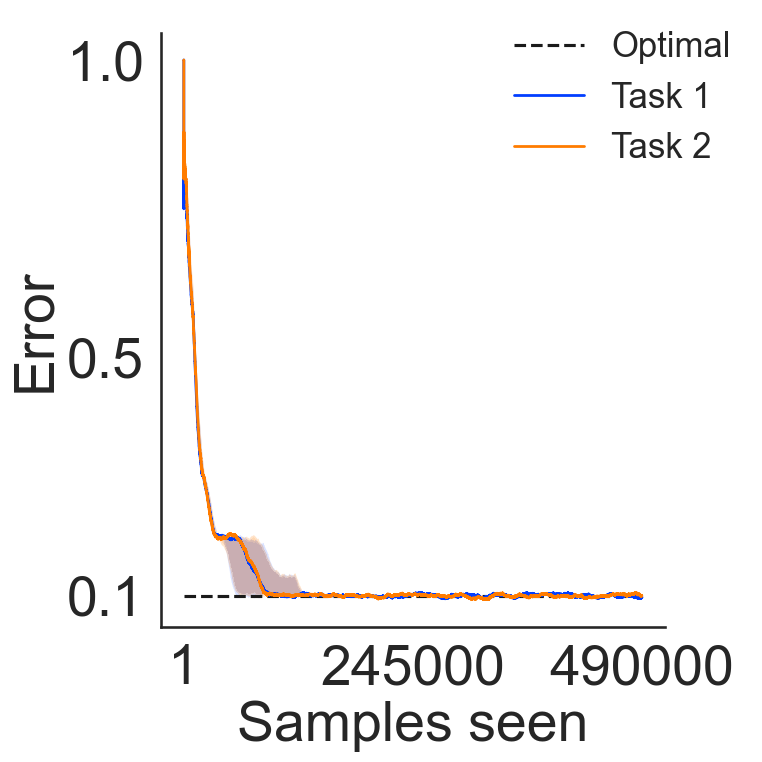

In [190]:
sns.set(
        color_codes=True, palette="bright", style="white", context="talk", font_scale=1.5
    )
font = 40
samples_to_show = 490000

fig, ax = plt.subplots(1, 1, figsize=(8,8))

ax.hlines(0.1, 0, samples_to_show, linestyles='dashed', label='Optimal', color='k')

ax.plot(np.arange(1,samples_to_show+1), np.median(1-test_acc1[:,:samples_to_show],axis=0),linewidth=2, label='Task 1')
ax.fill_between(np.arange(1,samples_to_show+1), np.quantile(1-test_acc1[:,:samples_to_show], 0.25, axis=0), np.quantile(1-test_acc1[:,:samples_to_show], 0.75, axis=0), alpha=.3)

ax.plot(np.arange(1,samples_to_show+1), np.median(1-test_acc2[:,:samples_to_show],axis=0),linewidth=2, label='Task 2')
ax.fill_between(np.arange(1,samples_to_show+1), np.quantile(1-test_acc2[:,:samples_to_show], 0.25, axis=0), np.quantile(1-test_acc2[:,:samples_to_show], 0.75, axis=0), alpha=.3)

leg = fig.legend(fontsize=25, frameon=False)


ax.set_xticks([1, samples_to_show//2, samples_to_show])
ax.set_yticks([0.1, 0.5, 1.0])

ax.set_xlabel('Samples seen', fontsize=font)
ax.set_ylabel('Error', fontsize=font)

ax.tick_params(labelsize=40)
right_side = ax.spines["right"]
right_side.set_visible(False)
top_side = ax.spines["top"]
top_side.set_visible(False)

plt.tight_layout()


## Perform the experiment for single headed sequential training (each repeated 10 times). Note that it results in forgetting of Task 1.

In [193]:
reps = 10
layer_no = [1,2,3,4,5]
lr = 1e-2
window = 8
test_acc1 = np.zeros((reps, len(data)), dtype=float)
test_acc2 = np.zeros((reps, len(data)), dtype=float)

task1 = Dataset_converter(data, window)
task2 = Dataset_converter(data, window, task=2)

for rep in tqdm(range(reps)):
    torch.manual_seed(rep)
    model = cnn()
    train_loader_task1 = DataLoader(task1, batch_size=1, shuffle=False) 
    train_loader_task2 = DataLoader(task2, batch_size=1, shuffle=False) 
    
    optimizer = torch.optim.SGD(model.parameters(), lr=lr, momentum=0.9)
    criterion = torch.nn.MSELoss()

    total = 0
    correct1 = np.zeros(10000,dtype=float)
    correct2 = np.zeros(10000,dtype=float)
    jj = 0
    for (X1, y1), (X2, y2) in zip(train_loader_task1, train_loader_task2):
        optimizer.zero_grad()

        if jj < 250000:
            predicted_y1 = model(X1)
            loss = criterion(predicted_y1, y1)
            loss.backward()
            optimizer.step()
        else:
            predicted_y2 = model(X2)
            loss = criterion(predicted_y2, y2)
            loss.backward()
            optimizer.step()

        with torch.no_grad():
            total += 1

            if jj < 250000:
                predicted_y2 = model(X2)
            else:
                predicted_y1 = model(X1)

            if y1.argmax() == predicted_y1.argmax():
                    correct1[jj%10000] = 1
            else:
                correct1[jj%10000] = 0

            if y2.argmax() == predicted_y2.argmax():
                    correct2[jj%10000] = 1
            else:
                correct2[jj%10000] = 0

            test_acc1[rep,jj] = np.sum(correct1)/total if total<10000 else np.sum(correct1)/10000
            test_acc2[rep,jj] = np.sum(correct2)/total if total<10000 else np.sum(correct2)/10000

            if jj%10000==0:
                print(f'Iter : {jj+1}, loss: {loss:.4f}, accuracy task 1: {test_acc1[rep,jj]}, accuracy task 2: {test_acc2[rep,jj]}')
            jj += 1
            

  0%|                                                                                                                                                   | 0/10 [00:00<?, ?it/s]/var/folders/gv/wp457yys7h73m9dkm35g8l4r0000gn/T/ipykernel_34924/1982273616.py:33: UserWarning: Implicit dimension choice for softmax has been deprecated. Change the call to include dim=X as an argument.
  x = torch.nn.functional.softmax(x)


Iter : 1, loss: 0.1341, accuracy task 1: 0.0, accuracy task 2: 0.0
Iter : 10001, loss: 0.0718, accuracy task 1: 0.521, accuracy task 2: 0.5285
Iter : 20001, loss: 0.0007, accuracy task 1: 0.7936, accuracy task 2: 0.7925
Iter : 30001, loss: 0.0027, accuracy task 1: 0.8158, accuracy task 2: 0.7785
Iter : 40001, loss: 0.0000, accuracy task 1: 0.9026, accuracy task 2: 0.7043
Iter : 50001, loss: 0.0000, accuracy task 1: 0.9029, accuracy task 2: 0.7047
Iter : 60001, loss: 0.0000, accuracy task 1: 0.8959, accuracy task 2: 0.6984
Iter : 70001, loss: 0.0000, accuracy task 1: 0.9007, accuracy task 2: 0.7021
Iter : 80001, loss: 0.0000, accuracy task 1: 0.9012, accuracy task 2: 0.7038
Iter : 90001, loss: 0.0000, accuracy task 1: 0.8989, accuracy task 2: 0.6997
Iter : 100001, loss: 0.0000, accuracy task 1: 0.8966, accuracy task 2: 0.6985
Iter : 110001, loss: 0.0000, accuracy task 1: 0.8972, accuracy task 2: 0.6992
Iter : 120001, loss: 0.0000, accuracy task 1: 0.8996, accuracy task 2: 0.7009
Iter : 

 10%|█████████████▊                                                                                                                            | 1/10 [02:34<23:11, 154.64s/it]

Iter : 1, loss: 0.1222, accuracy task 1: 0.0, accuracy task 2: 1.0
Iter : 10001, loss: 0.0553, accuracy task 1: 0.4983, accuracy task 2: 0.4961
Iter : 20001, loss: 0.0005, accuracy task 1: 0.7711, accuracy task 2: 0.7726
Iter : 30001, loss: 0.0002, accuracy task 1: 0.8209, accuracy task 2: 0.7772
Iter : 40001, loss: 0.0002, accuracy task 1: 0.9022, accuracy task 2: 0.708
Iter : 50001, loss: 0.0000, accuracy task 1: 0.9038, accuracy task 2: 0.7061
Iter : 60001, loss: 0.0000, accuracy task 1: 0.8952, accuracy task 2: 0.6981
Iter : 70001, loss: 0.0000, accuracy task 1: 0.9021, accuracy task 2: 0.7039
Iter : 80001, loss: 0.0000, accuracy task 1: 0.8997, accuracy task 2: 0.702
Iter : 90001, loss: 0.0000, accuracy task 1: 0.8985, accuracy task 2: 0.7012
Iter : 100001, loss: 0.0000, accuracy task 1: 0.8986, accuracy task 2: 0.7011
Iter : 110001, loss: 0.0000, accuracy task 1: 0.8983, accuracy task 2: 0.7006
Iter : 120001, loss: 0.0000, accuracy task 1: 0.9001, accuracy task 2: 0.7018
Iter : 1

 20%|███████████████████████████▌                                                                                                              | 2/10 [05:08<20:32, 154.05s/it]

...

 80%|██████████████████████████████████████████████████████████████████████████████████████████████████████████████▍                           | 8/10 [20:32<05:07, 153.92s/it]

Iter : 1, loss: 0.1135, accuracy task 1: 1.0, accuracy task 2: 0.0
Iter : 10001, loss: 0.0789, accuracy task 1: 0.4975, accuracy task 2: 0.502
Iter : 20001, loss: 0.0027, accuracy task 1: 0.7777, accuracy task 2: 0.7741
Iter : 30001, loss: 0.0000, accuracy task 1: 0.8586, accuracy task 2: 0.7389
Iter : 40001, loss: 0.0000, accuracy task 1: 0.8993, accuracy task 2: 0.7069
Iter : 50001, loss: 0.0000, accuracy task 1: 0.9053, accuracy task 2: 0.7073
Iter : 60001, loss: 0.0000, accuracy task 1: 0.8967, accuracy task 2: 0.6997
Iter : 70001, loss: 0.0000, accuracy task 1: 0.8982, accuracy task 2: 0.7038
Iter : 80001, loss: 0.0000, accuracy task 1: 0.8999, accuracy task 2: 0.7022
Iter : 90001, loss: 0.0000, accuracy task 1: 0.8983, accuracy task 2: 0.701
Iter : 100001, loss: 0.0000, accuracy task 1: 0.8983, accuracy task 2: 0.701
Iter : 110001, loss: 0.0000, accuracy task 1: 0.8975, accuracy task 2: 0.7007
Iter : 120001, loss: 0.0000, accuracy task 1: 0.9001, accuracy task 2: 0.7015
Iter : 13

 90%|████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████▏             | 9/10 [23:06<02:33, 153.95s/it]

Iter : 1, loss: 0.1288, accuracy task 1: 0.0, accuracy task 2: 0.0
Iter : 10001, loss: 0.0699, accuracy task 1: 0.5445, accuracy task 2: 0.545
Iter : 20001, loss: 0.0031, accuracy task 1: 0.7705, accuracy task 2: 0.7733
Iter : 30001, loss: 0.0021, accuracy task 1: 0.8007, accuracy task 2: 0.7988
Iter : 40001, loss: 0.0000, accuracy task 1: 0.8036, accuracy task 2: 0.8002
Iter : 50001, loss: 0.0001, accuracy task 1: 0.8017, accuracy task 2: 0.804
Iter : 60001, loss: 0.0000, accuracy task 1: 0.796, accuracy task 2: 0.7951
Iter : 70001, loss: 0.0000, accuracy task 1: 0.8024, accuracy task 2: 0.8023
Iter : 80001, loss: 0.0000, accuracy task 1: 0.8027, accuracy task 2: 0.7982
Iter : 90001, loss: 0.0000, accuracy task 1: 0.7991, accuracy task 2: 0.798
Iter : 100001, loss: 0.0000, accuracy task 1: 0.7993, accuracy task 2: 0.7954
Iter : 110001, loss: 0.0001, accuracy task 1: 0.8017, accuracy task 2: 0.7964
Iter : 120001, loss: 0.0000, accuracy task 1: 0.8026, accuracy task 2: 0.7967
Iter : 130

100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 10/10 [25:40<00:00, 154.01s/it]


# Plot the result

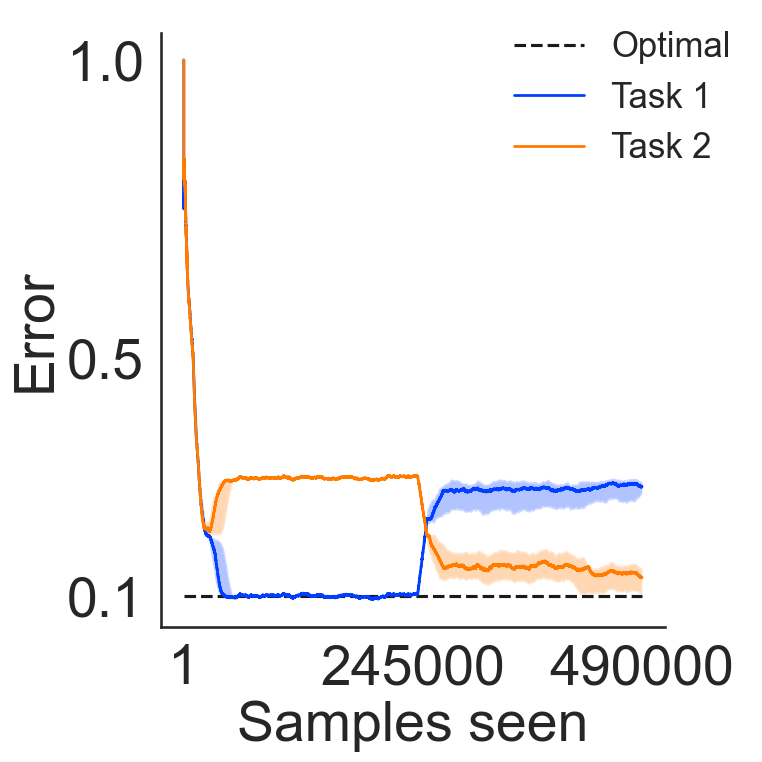

In [194]:
sns.set(
        color_codes=True, palette="bright", style="white", context="talk", font_scale=1.5
    )
font = 40
samples_to_show = 490000

fig, ax = plt.subplots(1, 1, figsize=(8,8))

ax.hlines(0.1, 0, samples_to_show, linestyles='dashed', label='Optimal', color='k')

ax.plot(np.arange(1,samples_to_show+1), np.median(1-test_acc1[:,:samples_to_show],axis=0),linewidth=2, label='Task 1')
ax.fill_between(np.arange(1,samples_to_show+1), np.quantile(1-test_acc1[:,:samples_to_show], 0.25, axis=0), np.quantile(1-test_acc1[:,:samples_to_show], 0.75, axis=0), alpha=.3)

ax.plot(np.arange(1,samples_to_show+1), np.median(1-test_acc2[:,:samples_to_show],axis=0),linewidth=2, label='Task 2')
ax.fill_between(np.arange(1,samples_to_show+1), np.quantile(1-test_acc2[:,:samples_to_show], 0.25, axis=0), np.quantile(1-test_acc2[:,:samples_to_show], 0.75, axis=0), alpha=.3)

leg = fig.legend(fontsize=25, frameon=False)


ax.set_xticks([1, samples_to_show//2, samples_to_show])
ax.set_yticks([0.1, 0.5, 1.0])

ax.set_xlabel('Samples seen', fontsize=font)
ax.set_ylabel('Error', fontsize=font)

ax.tick_params(labelsize=40)
right_side = ax.spines["right"]
right_side.set_visible(False)
top_side = ax.spines["top"]
top_side.set_visible(False)

plt.tight_layout()


## Perform the experiment for single headed interleaved training (each repeated 10 times). Note that it results in forgetting of Task 1.

In [195]:
reps = 10
layer_no = [1,2,3,4,5]
lr = 1e-2
window = 8
test_acc1 = np.zeros((reps, len(data)), dtype=float)
test_acc2 = np.zeros((reps, len(data)), dtype=float)

task1 = Dataset_converter(data, window)
task2 = Dataset_converter(data, window, task=2)

for rep in tqdm(range(reps)):
    torch.manual_seed(rep)
    model = cnn()
    train_loader_task1 = DataLoader(task1, batch_size=1, shuffle=False) 
    train_loader_task2 = DataLoader(task2, batch_size=1, shuffle=False) 
    
    optimizer = torch.optim.SGD(model.parameters(), lr=lr, momentum=0.9)
    criterion = torch.nn.MSELoss()

    total = 0
    correct1 = np.zeros(10000,dtype=float)
    correct2 = np.zeros(10000,dtype=float)
    jj = 0
    for (X1, y1), (X2, y2) in zip(train_loader_task1, train_loader_task2):
        optimizer.zero_grad()

        if jj%2:
            predicted_y1 = model(X1)
            loss = criterion(predicted_y1, y1)
            loss.backward()
            optimizer.step()
        else:
            predicted_y2 = model(X2)
            loss = criterion(predicted_y2, y2)
            loss.backward()
            optimizer.step()

        with torch.no_grad():
            total += 1

            if jj%2:
                predicted_y2 = model(X2)
            else:
                predicted_y1 = model(X1)

            if y1.argmax() == predicted_y1.argmax():
                    correct1[jj%10000] = 1
            else:
                correct1[jj%10000] = 0

            if y2.argmax() == predicted_y2.argmax():
                    correct2[jj%10000] = 1
            else:
                correct2[jj%10000] = 0

            test_acc1[rep,jj] = np.sum(correct1)/total if total<10000 else np.sum(correct1)/10000
            test_acc2[rep,jj] = np.sum(correct2)/total if total<10000 else np.sum(correct2)/10000

            if jj%10000==0:
                print(f'Iter : {jj+1}, loss: {loss:.4f}, accuracy task 1: {test_acc1[rep,jj]}, accuracy task 2: {test_acc2[rep,jj]}')
            jj += 1
            

  0%|                                                                                                                                                   | 0/10 [00:00<?, ?it/s]/var/folders/gv/wp457yys7h73m9dkm35g8l4r0000gn/T/ipykernel_34924/1982273616.py:33: UserWarning: Implicit dimension choice for softmax has been deprecated. Change the call to include dim=X as an argument.
  x = torch.nn.functional.softmax(x)


Iter : 1, loss: 0.1218, accuracy task 1: 0.0, accuracy task 2: 0.0
Iter : 10001, loss: 0.0227, accuracy task 1: 0.519, accuracy task 2: 0.5201
Iter : 20001, loss: 0.0007, accuracy task 1: 0.7867, accuracy task 2: 0.7919
Iter : 30001, loss: 0.0000, accuracy task 1: 0.8008, accuracy task 2: 0.7973
Iter : 40001, loss: 0.0000, accuracy task 1: 0.803, accuracy task 2: 0.8034
Iter : 50001, loss: 0.0001, accuracy task 1: 0.8023, accuracy task 2: 0.8016
Iter : 60001, loss: 0.0001, accuracy task 1: 0.7936, accuracy task 2: 0.7992
Iter : 70001, loss: 0.0001, accuracy task 1: 0.8053, accuracy task 2: 0.7984
Iter : 80001, loss: 0.0000, accuracy task 1: 0.8027, accuracy task 2: 0.7981
Iter : 90001, loss: 0.0000, accuracy task 1: 0.7933, accuracy task 2: 0.804
Iter : 100001, loss: 0.0000, accuracy task 1: 0.7975, accuracy task 2: 0.7982
Iter : 110001, loss: 0.0000, accuracy task 1: 0.8001, accuracy task 2: 0.7946
Iter : 120001, loss: 0.0000, accuracy task 1: 0.8016, accuracy task 2: 0.8002
Iter : 13

 10%|█████████████▊                                                                                                                            | 1/10 [02:33<23:00, 153.40s/it]

Iter : 1, loss: 0.1170, accuracy task 1: 0.0, accuracy task 2: 1.0
Iter : 10001, loss: 0.0950, accuracy task 1: 0.4951, accuracy task 2: 0.4915
Iter : 20001, loss: 0.0015, accuracy task 1: 0.7624, accuracy task 2: 0.7626
Iter : 30001, loss: 0.0001, accuracy task 1: 0.8009, accuracy task 2: 0.7987
Iter : 40001, loss: 0.0006, accuracy task 1: 0.801, accuracy task 2: 0.8054
Iter : 50001, loss: 0.0001, accuracy task 1: 0.8027, accuracy task 2: 0.8003
Iter : 60001, loss: 0.0003, accuracy task 1: 0.7936, accuracy task 2: 0.7963
Iter : 70001, loss: 0.0000, accuracy task 1: 0.806, accuracy task 2: 0.7964
Iter : 80001, loss: 0.0000, accuracy task 1: 0.803, accuracy task 2: 0.799
Iter : 90001, loss: 0.0000, accuracy task 1: 0.7942, accuracy task 2: 0.8015
Iter : 100001, loss: 0.0000, accuracy task 1: 0.7985, accuracy task 2: 0.7961
Iter : 110001, loss: 0.0000, accuracy task 1: 0.8012, accuracy task 2: 0.7955
Iter : 120001, loss: 0.0000, accuracy task 1: 0.8001, accuracy task 2: 0.7989
Iter : 130

 20%|███████████████████████████▌                                                                                                              | 2/10 [05:07<20:30, 153.77s/it]

...

 80%|██████████████████████████████████████████████████████████████████████████████████████████████████████████████▍                           | 8/10 [20:36<05:08, 154.32s/it]

Iter : 1, loss: 0.1170, accuracy task 1: 1.0, accuracy task 2: 0.0
Iter : 10001, loss: 0.0121, accuracy task 1: 0.5071, accuracy task 2: 0.5064
Iter : 20001, loss: 0.0035, accuracy task 1: 0.7219, accuracy task 2: 0.7196
Iter : 30001, loss: 0.0000, accuracy task 1: 0.7901, accuracy task 2: 0.7855
Iter : 40001, loss: 0.0002, accuracy task 1: 0.8025, accuracy task 2: 0.7983
Iter : 50001, loss: 0.0001, accuracy task 1: 0.8039, accuracy task 2: 0.8018
Iter : 60001, loss: 0.0008, accuracy task 1: 0.7977, accuracy task 2: 0.7959
Iter : 70001, loss: 0.0000, accuracy task 1: 0.8071, accuracy task 2: 0.797
Iter : 80001, loss: 0.0001, accuracy task 1: 0.8031, accuracy task 2: 0.7976
Iter : 90001, loss: 0.0000, accuracy task 1: 0.7953, accuracy task 2: 0.8007
Iter : 100001, loss: 0.0000, accuracy task 1: 0.7982, accuracy task 2: 0.795
Iter : 110001, loss: 0.0000, accuracy task 1: 0.8012, accuracy task 2: 0.7975
Iter : 120001, loss: 0.0000, accuracy task 1: 0.8003, accuracy task 2: 0.7985
Iter : 1

 90%|████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████▏             | 9/10 [23:11<02:34, 154.55s/it]

Iter : 1, loss: 0.1276, accuracy task 1: 0.0, accuracy task 2: 0.0
Iter : 10001, loss: 0.0059, accuracy task 1: 0.5501, accuracy task 2: 0.5497
Iter : 20001, loss: 0.0005, accuracy task 1: 0.7987, accuracy task 2: 0.7994
Iter : 30001, loss: 0.0000, accuracy task 1: 0.7967, accuracy task 2: 0.7998
Iter : 40001, loss: 0.0001, accuracy task 1: 0.8003, accuracy task 2: 0.8036
Iter : 50001, loss: 0.0002, accuracy task 1: 0.8046, accuracy task 2: 0.8005
Iter : 60001, loss: 0.0001, accuracy task 1: 0.7948, accuracy task 2: 0.7986
Iter : 70001, loss: 0.0000, accuracy task 1: 0.804, accuracy task 2: 0.7991
Iter : 80001, loss: 0.0000, accuracy task 1: 0.8029, accuracy task 2: 0.7965
Iter : 90001, loss: 0.0000, accuracy task 1: 0.7963, accuracy task 2: 0.8019
Iter : 100001, loss: 0.0000, accuracy task 1: 0.7989, accuracy task 2: 0.7948
Iter : 110001, loss: 0.0000, accuracy task 1: 0.8019, accuracy task 2: 0.7954
Iter : 120001, loss: 0.0000, accuracy task 1: 0.801, accuracy task 2: 0.7984
Iter : 1

100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 10/10 [25:44<00:00, 154.50s/it]


# Plot the result

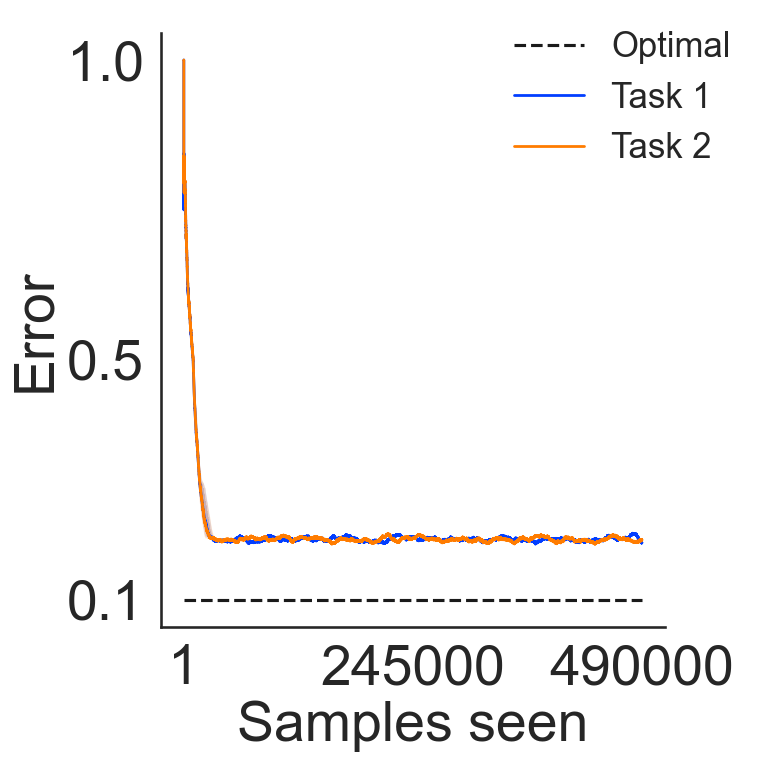

In [197]:
sns.set(
        color_codes=True, palette="bright", style="white", context="talk", font_scale=1.5
    )
font = 40
samples_to_show = 490000

fig, ax = plt.subplots(1, 1, figsize=(8,8))

ax.hlines(0.1, 0, samples_to_show, linestyles='dashed', label='Optimal', color='k')

ax.plot(np.arange(1,samples_to_show+1), np.median(1-test_acc1[:,:samples_to_show],axis=0),linewidth=2, label='Task 1')
ax.fill_between(np.arange(1,samples_to_show+1), np.quantile(1-test_acc1[:,:samples_to_show], 0.25, axis=0), np.quantile(1-test_acc1[:,:samples_to_show], 0.75, axis=0), alpha=.3)

ax.plot(np.arange(1,samples_to_show+1), np.median(1-test_acc2[:,:samples_to_show],axis=0),linewidth=2, label='Task 2')
ax.fill_between(np.arange(1,samples_to_show+1), np.quantile(1-test_acc2[:,:samples_to_show], 0.25, axis=0), np.quantile(1-test_acc2[:,:samples_to_show], 0.75, axis=0), alpha=.3)

leg = fig.legend(fontsize=25, frameon=False)


ax.set_xticks([1, samples_to_show//2, samples_to_show])
ax.set_yticks([0.1, 0.5, 1.0])

ax.set_xlabel('Samples seen', fontsize=font)
ax.set_ylabel('Error', fontsize=font)

ax.tick_params(labelsize=40)
right_side = ax.spines["right"]
right_side.set_visible(False)
top_side = ax.spines["top"]
top_side.set_visible(False)

plt.tight_layout()
